<a href="https://colab.research.google.com/github/A8stern/ml_mobile_1/blob/main/lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ковалев Глеб 367291 Лабораторная 4
# Анализ текстовых данных

##0 Imports

In [2]:
import os
import re
import math
import time
import json
import pickle
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter, defaultdict
from tqdm.notebook import tqdm

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer

from scipy.sparse import csr_matrix

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)
nltk.download('omw-1.4', quiet=True)

True

## Данные (3 балла)

##1 Сбор данных с OpenAlex

Соберём не менее 10k англоязычных записей с OpenAlex по 4 доменным областям. Для каждой записи сохраним поля `id`, `title`, `abstract`, `domain`. Используем cursor-пагинацию.

In [3]:
def reconstruct_abstract(inverted_index):
    if not inverted_index:
        return None
    positions = {}
    for word, idx_list in inverted_index.items():
        for idx in idx_list:
            positions[idx] = word
    if not positions:
        return None
    return ' '.join(positions[i] for i in sorted(positions.keys()))


def fetch_openalex_domain(domain_id, target_count=2700, per_page=200, mailto=None):
    base_url = "https://api.openalex.org/works"
    cursor = "*"
    collected = []
    seen_ids = set()
    pbar = tqdm(total=target_count, desc=f"domain {domain_id}")
    while len(collected) < target_count:
        params = {
            "filter": f"primary_topic.domain.id:domains/{domain_id},language:languages/en,has_abstract:true",
            "per-page": per_page,
            "cursor": cursor,
            "select": "id,title,abstract_inverted_index,primary_topic",
        }
        if mailto:
            params["mailto"] = mailto
        r = requests.get(base_url, params=params, timeout=60)
        r.raise_for_status()
        data = r.json()
        results = data.get("results", [])
        if not results:
            break
        for w in results:
            wid = w.get("id")
            title = w.get("title")
            abstract = reconstruct_abstract(w.get("abstract_inverted_index"))
            primary = w.get("primary_topic") or {}
            domain_info = (primary.get("domain") or {})
            domain_name = domain_info.get("display_name")
            if not (wid and title and abstract and domain_name):
                continue
            if wid in seen_ids:
                continue
            seen_ids.add(wid)
            collected.append({
                "id": wid,
                "title": title,
                "abstract": abstract,
                "domain": domain_name,
            })
            pbar.update(1)
            if len(collected) >= target_count:
                break
        cursor = (data.get("meta") or {}).get("next_cursor")
        if not cursor:
            break
        time.sleep(0.1)
    pbar.close()
    return collected


all_records = []
for did in [1, 2, 3, 4]:
    all_records.extend(fetch_openalex_domain(did, target_count=2700))

df = pd.DataFrame(all_records).drop_duplicates(subset=['id']).reset_index(drop=True)
df.to_csv('openalex_works.csv', index=False)
df.head()

domain 1:   0%|          | 0/2700 [00:00<?, ?it/s]

domain 2:   0%|          | 0/2700 [00:00<?, ?it/s]

domain 3:   0%|          | 0/2700 [00:00<?, ?it/s]

domain 4:   0%|          | 0/2700 [00:00<?, ?it/s]

,id,title,abstract,domain
0,https://openalex.org/W2144634347,Molecular Cloning: A Laboratory Manual,Molecular Cloning has served as the foundation...,Life Sciences
1,https://openalex.org/W2179438025,Moderated estimation of fold change and disper...,In comparative high-throughput sequencing assa...,Life Sciences
2,https://openalex.org/W2158714788,Gapped BLAST and PSI-BLAST: a new generation o...,The BLAST programs are widely used tools for s...,Life Sciences
3,https://openalex.org/W2131271579,Trimmomatic: a flexible trimmer for Illumina s...,MOTIVATION: Although many next-generation sequ...,Life Sciences
4,https://openalex.org/W2108234281,The Sequence Alignment/Map format and SAMtools,SUMMARY: The Sequence Alignment/Map (SAM) form...,Life Sciences


##2 Анализ данных

Минимально выводим: общее количество записей; количество уникальных значений для доменных областей; распределение количества символов и слов для `title` и `abstract`.

In [4]:
print(f"Всего записей: {len(df)}")
print(f"Уникальных доменов: {df['domain'].nunique()}")
print(df['domain'].value_counts())

Всего записей: 10800
Уникальных доменов: 4
domain
Life Sciences        2700
Social Sciences      2700
Physical Sciences    2700
Health Sciences      2700
Name: count, dtype: int64


In [5]:
df['title_chars'] = df['title'].str.len()
df['abstract_chars'] = df['abstract'].str.len()
df['title_words'] = df['title'].str.split().apply(len)
df['abstract_words'] = df['abstract'].str.split().apply(len)

print(df[['title_chars', 'abstract_chars', 'title_words', 'abstract_words']].describe())

        title_chars  abstract_chars   title_words  abstract_words
count  10800.000000    10800.000000  10800.000000    10800.000000
mean      69.213981     1238.569815      9.196852      180.302315
std       35.918569     1367.366320      4.853169      216.335385
min        3.000000        1.000000      1.000000        1.000000
25%       44.000000      685.000000      6.000000       99.000000
50%       65.000000     1034.000000      9.000000      150.000000
75%       86.000000     1558.000000     12.000000      225.000000
max     1044.000000    29889.000000    144.000000     5077.000000


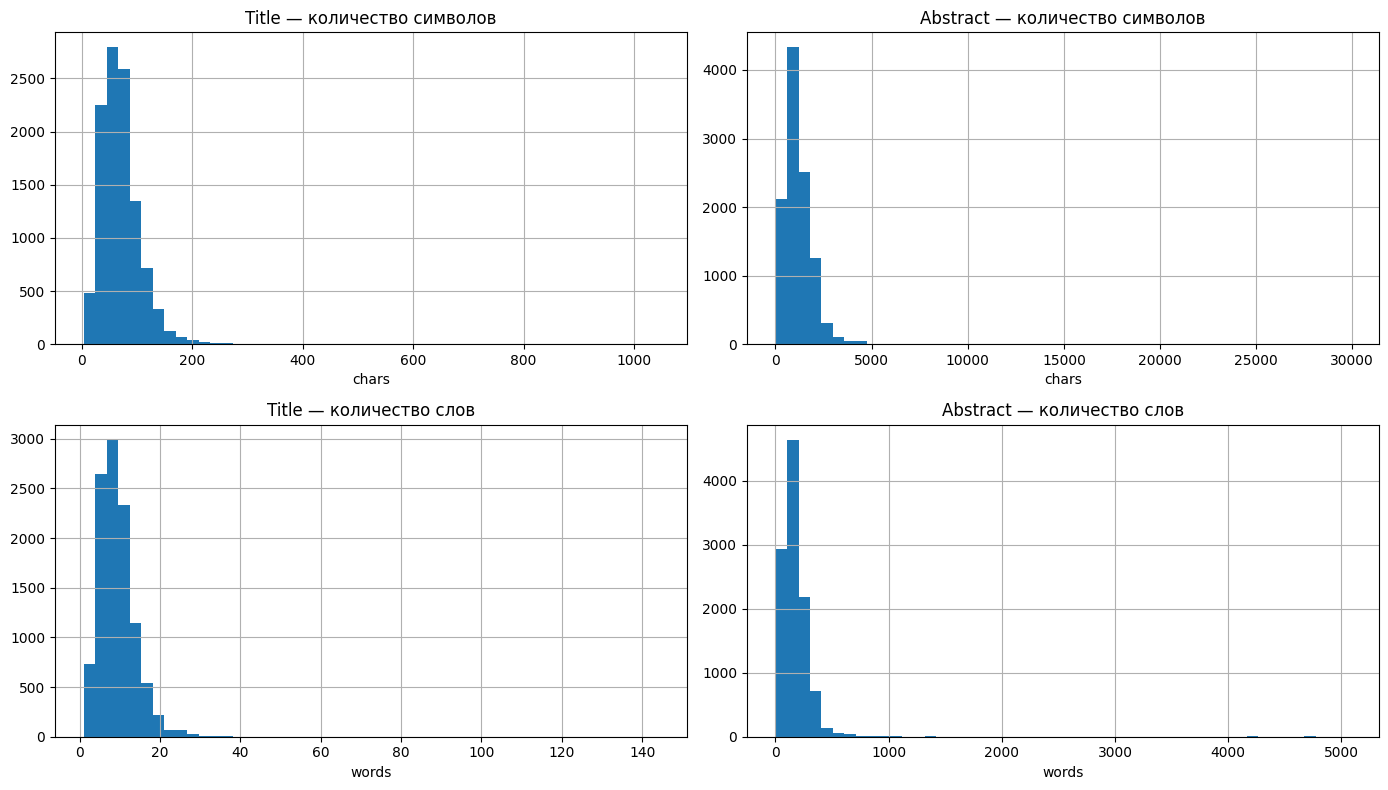

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

axes[0, 0].hist(df['title_chars'], bins=50)
axes[0, 0].set_title('Title — количество символов')
axes[0, 0].set_xlabel('chars')
axes[0, 0].grid(True)

axes[0, 1].hist(df['abstract_chars'], bins=50)
axes[0, 1].set_title('Abstract — количество символов')
axes[0, 1].set_xlabel('chars')
axes[0, 1].grid(True)

axes[1, 0].hist(df['title_words'], bins=50)
axes[1, 0].set_title('Title — количество слов')
axes[1, 0].set_xlabel('words')
axes[1, 0].grid(True)

axes[1, 1].hist(df['abstract_words'], bins=50)
axes[1, 1].set_title('Abstract — количество слов')
axes[1, 1].set_xlabel('words')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

##3 Предобработка текста

Приведение к нижнему регистру, удаление пунктуации и чисел, лемматизация, удаление стоп-слов, удаление лишних пробельных символов. Объединяем `title` и `abstract` в один текст.

In [7]:
STOP_WORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()


def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    tokens = text.split()
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens if t not in STOP_WORDS and len(t) > 1]
    return ' '.join(tokens)


df['title_abstract'] = df['title'].fillna('') + ' ' + df['abstract'].fillna('')
df['title_abstract_preprocessed'] = df['title_abstract'].apply(preprocess_text)
df.head()

,id,title,abstract,domain,title_chars,abstract_chars,title_words,abstract_words,title_abstract,title_abstract_preprocessed
0,https://openalex.org/W2144634347,Molecular Cloning: A Laboratory Manual,Molecular Cloning has served as the foundation...,Life Sciences,38,1968,5,280,Molecular Cloning: A Laboratory Manual Molecul...,molecular cloning laboratory manual molecular ...
1,https://openalex.org/W2179438025,Moderated estimation of fold change and disper...,In comparative high-throughput sequencing assa...,Life Sciences,79,756,12,99,Moderated estimation of fold change and disper...,moderated estimation fold change dispersion rn...
2,https://openalex.org/W2158714788,Gapped BLAST and PSI-BLAST: a new generation o...,The BLAST programs are widely used tools for s...,Life Sciences,80,1095,12,157,Gapped BLAST and PSI-BLAST: a new generation o...,gapped blast psi blast new generation protein ...
3,https://openalex.org/W2131271579,Trimmomatic: a flexible trimmer for Illumina s...,MOTIVATION: Although many next-generation sequ...,Life Sciences,58,969,8,127,Trimmomatic: a flexible trimmer for Illumina s...,trimmomatic flexible trimmer illumina sequence...
4,https://openalex.org/W2108234281,The Sequence Alignment/Map format and SAMtools,SUMMARY: The Sequence Alignment/Map (SAM) form...,Life Sciences,46,634,6,88,The Sequence Alignment/Map format and SAMtools...,sequence alignment map format samtools summary...


##4 Базовые модели

В качестве алгоритмов классификации используем `MultinomialNB` и `LinearSVC` с `random_state=42`.

Разделяем данные в соотношении 80:20 ДО проведения любой векторизации.

In [8]:
clf1 = MultinomialNB()
clf2 = LinearSVC(random_state=42)

In [9]:
X = df['title_abstract_preprocessed'].values
y = df['domain'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Классы: {sorted(set(y))}")

Train: 8640, Test: 2160
Классы: ['Health Sciences', 'Life Sciences', 'Physical Sciences', 'Social Sciences']


In [10]:
def evaluate_clf(clf, X_train_v, y_train, X_test_v, y_test, title=''):
    t0 = time.time()
    clf.fit(X_train_v, y_train)
    fit_time = time.time() - t0

    t0 = time.time()
    y_pred = clf.predict(X_test_v)
    pred_time = time.time() - t0

    print(f"=== {title} ===")
    print(f"fit time: {fit_time:.3f}s, predict time: {pred_time:.3f}s")
    print(classification_report(y_test, y_pred))

    labels = sorted(set(y_test))
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.title(f'Confusion matrix — {title}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()
    return clf

## Bag of Words (3 балла)

##1 Реализация класса BagOfWords

Параметр `max_features` отвечает за фиксированную длину вектора и определяет максимальный размер словаря (выбираются самые частотные n-граммы).

In [11]:
class BagOfWords:
    def __init__(self, ngram_range=(1, 1), max_features=None):
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.vocabulary = {}
        self._index = {}

    def tokenize(self, text):
        return re.findall(r"[a-zA-Zа-яА-ЯёЁ]+", text.lower())

    def _make_ngrams(self, tokens):
        result = []
        lo, hi = self.ngram_range
        for n in range(lo, hi + 1):
            for i in range(len(tokens) - n + 1):
                result.append(' '.join(tokens[i:i + n]))
        return result

    def fit(self, documents):
        counter = Counter()
        for doc in documents:
            tokens = self.tokenize(doc)
            counter.update(self._make_ngrams(tokens))
        if self.max_features is not None:
            most_common = counter.most_common(self.max_features)
        else:
            most_common = counter.most_common()
        self.vocabulary = {term: count for term, count in most_common}
        self._index = {term: i for i, term in enumerate(self.vocabulary.keys())}

    def transform(self, documents):
        if not len(self.vocabulary):
            raise ValueError("The vocabulary has not been created. Call fit method first.")
        size = len(self.vocabulary)
        vectors = np.zeros((len(documents), size), dtype=np.int64)
        for i, doc in enumerate(documents):
            tokens = self.tokenize(doc)
            ngrams = self._make_ngrams(tokens)
            for ng in ngrams:
                idx = self._index.get(ng)
                if idx is not None:
                    vectors[i, idx] += 1
        return vectors

    def fit_transform(self, documents):
        self.fit(documents)
        return self.transform(documents)

In [12]:
bow = BagOfWords(ngram_range=(1, 2), max_features=15)

test_sentences = [
    "BoW transforms text into a frequency vector based on words occurrence",
    "in BoW each word's count creates a unique feature",
    "BoW ignores word order focusing on word occurrence frequency",
]

vectors = bow.fit_transform(test_sentences)
pd.DataFrame(vectors, columns=list(bow.vocabulary.keys()))

,bow,word,a,frequency,on,occurrence,transforms,text,into,vector,based,words,bow transforms,transforms text,text into
0,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1
1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
2,1,2,0,1,1,1,0,0,0,0,0,0,0,0,0


##2 Векторизация и обучение классификаторов

=== BoW (свой) + MultinomialNB ===
fit time: 11.949s, predict time: 0.342s
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.73      0.79       540
    Life Sciences       0.79      0.76      0.78       540
Physical Sciences       0.83      0.84      0.83       540
  Social Sciences       0.77      0.90      0.83       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



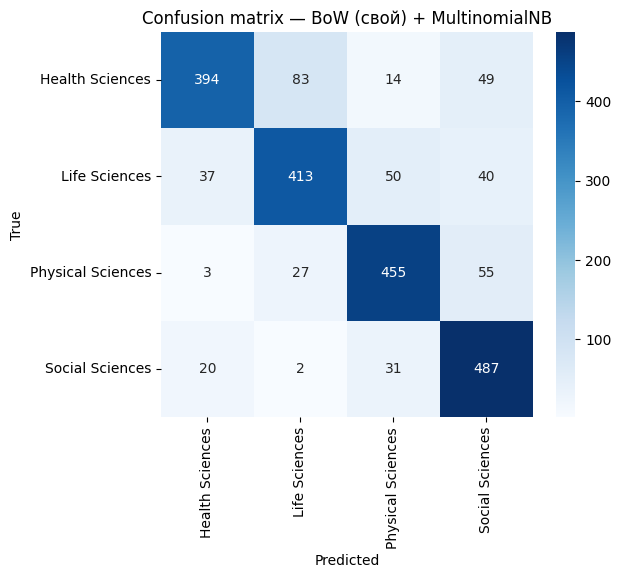

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=== BoW (свой) + LinearSVC ===
fit time: 5.809s, predict time: 0.171s
                   precision    recall  f1-score   support

  Health Sciences       0.80      0.77      0.79       540
    Life Sciences       0.75      0.75      0.75       540
Physical Sciences       0.78      0.80      0.79       540
  Social Sciences       0.80      0.81      0.81       540

         accuracy                           0.78      2160
        macro avg       0.78      0.78      0.78      2160
     weighted avg       0.78      0.78      0.78      2160



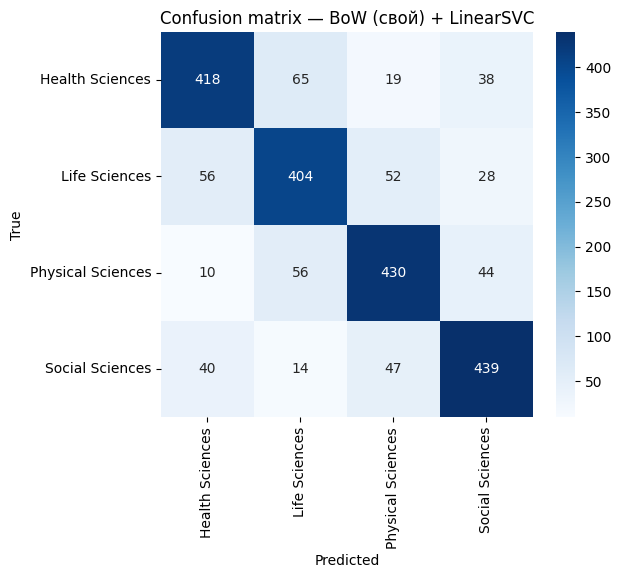

LinearSVC(random_state=42)

In [13]:
bow_my = BagOfWords(ngram_range=(1, 1), max_features=20000)
X_train_bow = bow_my.fit_transform(X_train)
X_test_bow = bow_my.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_bow, y_train, X_test_bow, y_test, title='BoW (свой) + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_bow, y_train, X_test_bow, y_test, title='BoW (свой) + LinearSVC')

=== BoW (1,2) + MultinomialNB ===
fit time: 25.970s, predict time: 0.699s
                   precision    recall  f1-score   support

  Health Sciences       0.89      0.70      0.79       540
    Life Sciences       0.76      0.78      0.77       540
Physical Sciences       0.83      0.84      0.84       540
  Social Sciences       0.77      0.91      0.84       540

         accuracy                           0.81      2160
        macro avg       0.82      0.81      0.81      2160
     weighted avg       0.82      0.81      0.81      2160



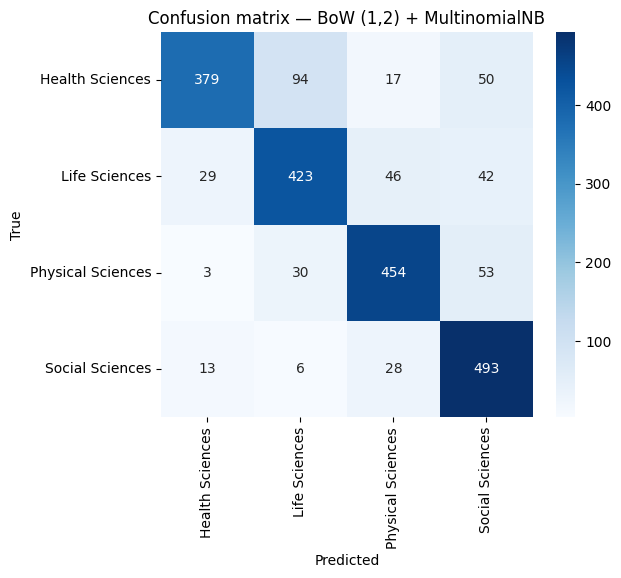

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=== BoW (1,2) + LinearSVC ===
fit time: 11.233s, predict time: 0.419s
                   precision    recall  f1-score   support

  Health Sciences       0.82      0.79      0.81       540
    Life Sciences       0.77      0.75      0.76       540
Physical Sciences       0.80      0.81      0.80       540
  Social Sciences       0.81      0.84      0.83       540

         accuracy                           0.80      2160
        macro avg       0.80      0.80      0.80      2160
     weighted avg       0.80      0.80      0.80      2160



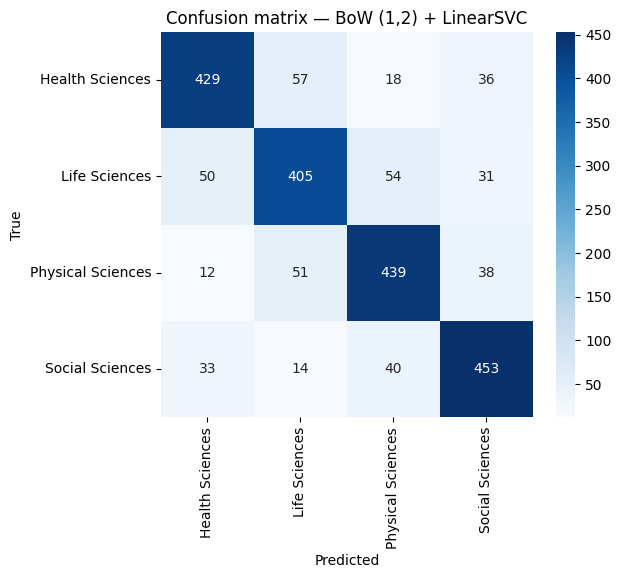

LinearSVC(random_state=42)

In [14]:
bow_my2 = BagOfWords(ngram_range=(1, 2), max_features=30000)
X_train_bow2 = bow_my2.fit_transform(X_train)
X_test_bow2 = bow_my2.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_bow2, y_train, X_test_bow2, y_test, title='BoW (1,2) + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_bow2, y_train, X_test_bow2, y_test, title='BoW (1,2) + LinearSVC')

##3 Готовая реализация CountVectorizer + GridSearch

=== CountVectorizer + MultinomialNB ===
fit time: 0.039s, predict time: 0.002s
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.73      0.79       540
    Life Sciences       0.78      0.77      0.78       540
Physical Sciences       0.83      0.84      0.84       540
  Social Sciences       0.77      0.90      0.83       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



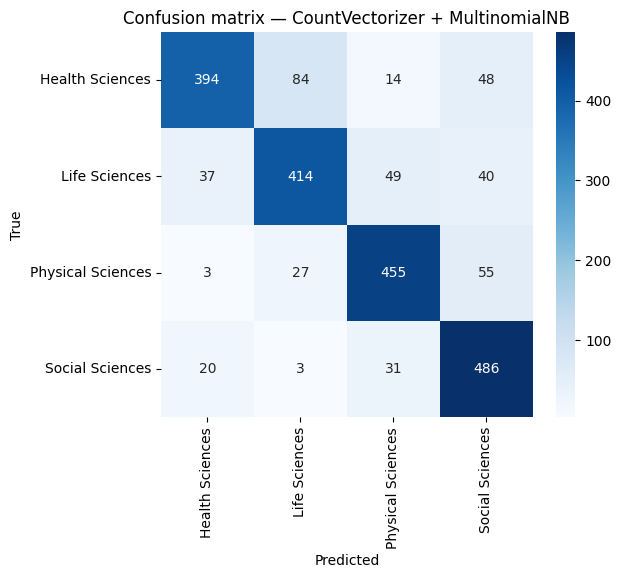

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


=== CountVectorizer + LinearSVC ===
fit time: 3.966s, predict time: 0.004s
                   precision    recall  f1-score   support

  Health Sciences       0.80      0.78      0.79       540
    Life Sciences       0.75      0.75      0.75       540
Physical Sciences       0.79      0.80      0.79       540
  Social Sciences       0.79      0.82      0.81       540

         accuracy                           0.78      2160
        macro avg       0.78      0.78      0.78      2160
     weighted avg       0.78      0.78      0.78      2160



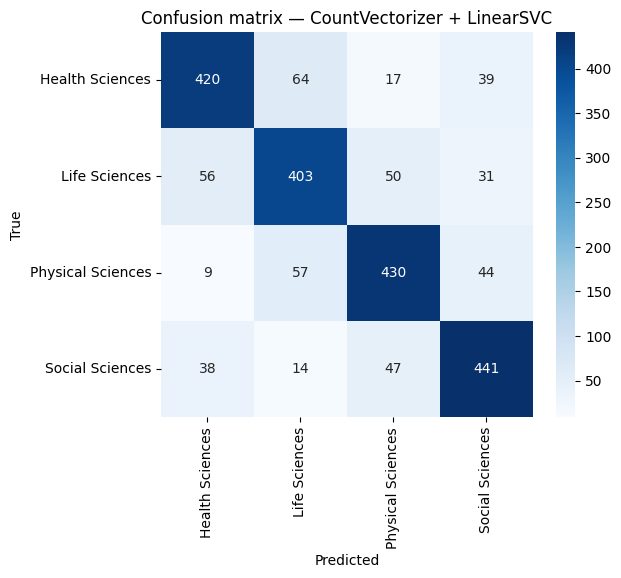

LinearSVC(random_state=42)

In [15]:
cv = CountVectorizer(max_features=20000, ngram_range=(1, 1))
X_train_cv = cv.fit_transform(X_train)
X_test_cv = cv.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_cv, y_train, X_test_cv, y_test, title='CountVectorizer + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_cv, y_train, X_test_cv, y_test, title='CountVectorizer + LinearSVC')

In [16]:
param_grid_cv = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__max_features': [10000, 20000, 50000],
    'vec__min_df': [1, 2, 5],
}

from sklearn.pipeline import Pipeline

pipe_nb = Pipeline([('vec', CountVectorizer()), ('clf', MultinomialNB())])
gs_nb = GridSearchCV(pipe_nb, param_grid_cv, cv=3, scoring='f1_macro', n_jobs=-1)
gs_nb.fit(X_train, y_train)
print('NB best params:', gs_nb.best_params_)
print('NB best CV score:', gs_nb.best_score_)
y_pred_nb = gs_nb.predict(X_test)
print(classification_report(y_test, y_pred_nb))

NB best params: {'vec__max_features': 50000, 'vec__min_df': 1, 'vec__ngram_range': (1, 2)}
NB best CV score: 0.8161629415133191
                   precision    recall  f1-score   support

  Health Sciences       0.89      0.71      0.79       540
    Life Sciences       0.77      0.78      0.78       540
Physical Sciences       0.83      0.85      0.84       540
  Social Sciences       0.78      0.91      0.84       540

         accuracy                           0.81      2160
        macro avg       0.82      0.81      0.81      2160
     weighted avg       0.82      0.81      0.81      2160



In [17]:
pipe_svc = Pipeline([('vec', CountVectorizer()), ('clf', LinearSVC(random_state=42))])
gs_svc = GridSearchCV(pipe_svc, param_grid_cv, cv=3, scoring='f1_macro', n_jobs=-1)
gs_svc.fit(X_train, y_train)
print('SVC best params:', gs_svc.best_params_)
print('SVC best CV score:', gs_svc.best_score_)
y_pred_svc = gs_svc.predict(X_test)
print(classification_report(y_test, y_pred_svc))

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


SVC best params: {'vec__max_features': 50000, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
SVC best CV score: 0.7807693857266571
                   precision    recall  f1-score   support

  Health Sciences       0.82      0.80      0.81       540
    Life Sciences       0.78      0.77      0.77       540
Physical Sciences       0.81      0.82      0.82       540
  Social Sciences       0.81      0.84      0.83       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



### Keywords (0.5 балла)

Топ-20 ключевых слов для каждого домена и общие топ-20 слов по всем доменам с использованием `CountVectorizer`.

In [18]:
def top_keywords_count(texts, labels, top_n=20):
    vec = CountVectorizer(max_features=50000, ngram_range=(1, 1))
    X_full = vec.fit_transform(texts)
    feature_names = np.array(vec.get_feature_names_out())

    overall_counts = np.asarray(X_full.sum(axis=0)).flatten()
    overall_top = feature_names[np.argsort(overall_counts)[::-1][:top_n]]
    print('Общие топ-{} слов:'.format(top_n))
    print(list(overall_top))

    print()
    domain_top = {}
    unique_domains = sorted(set(labels))
    for d in unique_domains:
        mask = np.array(labels) == d
        d_counts = np.asarray(X_full[mask].sum(axis=0)).flatten()
        other_counts = overall_counts - d_counts
        d_freq = d_counts / max(mask.sum(), 1)
        other_freq = other_counts / max((~mask).sum(), 1)
        score = d_freq - other_freq
        top = feature_names[np.argsort(score)[::-1][:top_n]]
        domain_top[d] = list(top)
        print(f'Домен: {d}')
        print(list(top))
        print()
    return overall_top, domain_top


_ = top_keywords_count(df['title_abstract_preprocessed'].values, df['domain'].values)

Общие топ-20 слов:
['data', 'patient', 'method', 'study', 'analysis', 'model', 'research', 'cell', 'disease', 'new', 'result', 'group', 'system', 'cancer', 'year', 'based', 'theory', 'also', 'risk', 'used']

Домен: Health Sciences
['patient', 'disease', 'cancer', 'group', 'risk', 'year', 'clinical', 'health', 'death', 'treatment', 'rate', 'percent', 'age', 'study', 'therapy', 'ci', 'mortality', 'care', 'per', 'among']

Домен: Life Sciences
['gene', 'cell', 'protein', 'sequence', 'genome', 'dna', 'plant', 'expression', 'human', 'specie', 'rna', 'pathway', 'brain', 'genetic', 'molecular', 'function', 'data', 'tool', 'stress', 'alignment']

Домен: Physical Sciences
['model', 'algorithm', 'problem', 'application', 'energy', 'network', 'system', 'image', 'method', 'material', 'property', 'altmetric', 'density', 'article', 'field', 'quantum', 'parameter', 'attention', 'linear', 'surface']

Домен: Social Sciences
['social', 'research', 'theory', 'firm', 'self', 'qualitative', 'economic', 'mar

## TF-IDF (3 балла)

##1 Реализация класса TFIDF

Используем формулу sklearn:

$$\text{IDF}(t, D) = \log\left(\frac{N+1}{\text{df}(t)+1}\right) + 1$$

При отборе `max_features` ориентируемся на term frequency.

In [19]:
class TFIDF:
    def __init__(self, ngram_range=(1, 1), max_features=None):
        self.ngram_range = ngram_range
        self.max_features = max_features
        self.vocabulary = {}
        self._index = {}
        self._idf = {}

    def tokenize(self, text):
        return re.findall(r"[a-zA-Zа-яА-ЯёЁ]+", text.lower())

    def _make_ngrams(self, tokens):
        result = []
        lo, hi = self.ngram_range
        for n in range(lo, hi + 1):
            for i in range(len(tokens) - n + 1):
                result.append(' '.join(tokens[i:i + n]))
        return result

    def fit(self, documents):
        n_docs = len(documents)
        tf_total = Counter()
        df_counter = Counter()
        for doc in documents:
            tokens = self.tokenize(doc)
            ngrams = self._make_ngrams(tokens)
            tf_total.update(ngrams)
            df_counter.update(set(ngrams))
        if self.max_features is not None:
            top = [t for t, _ in tf_total.most_common(self.max_features)]
        else:
            top = list(tf_total.keys())
        self._idf = {term: math.log((n_docs + 1) / (df_counter[term] + 1)) + 1 for term in top}
        self.vocabulary = {term: self._idf[term] for term in top}
        self._index = {term: i for i, term in enumerate(top)}

    def transform(self, documents):
        if not len(self.vocabulary):
            raise ValueError("The vocabulary has not been created. Call fit method first.")
        size = len(self.vocabulary)
        vectors = np.zeros((len(documents), size), dtype=np.float64)
        for i, doc in enumerate(documents):
            tokens = self.tokenize(doc)
            ngrams = self._make_ngrams(tokens)
            if not ngrams:
                continue
            tf = Counter(ngrams)
            total = sum(tf.values())
            for ng, cnt in tf.items():
                idx = self._index.get(ng)
                if idx is not None:
                    vectors[i, idx] = (cnt / total) * self._idf[ng]
        return vectors

    def fit_transform(self, documents):
        self.fit(documents)
        return self.transform(documents)

In [20]:
tfidf = TFIDF(ngram_range=(1, 2), max_features=15)

test_sentences = [
    "tf-idf measures word importance relative to its frequency in a document",
    "tf-idf considers word uniqueness across all documents in the corpus",
    "it identifies significant words common in a document yet rare across all documents"
]

vectors = tfidf.fit_transform(test_sentences)
pd.DataFrame(vectors, columns=list(tfidf.vocabulary.keys()))

,in,tf,idf,word,a,document,tf idf,in a,a document,across,all,documents,across all,all documents,measures
0,0.043478,0.055986,0.055986,0.055986,0.055986,0.055986,0.055986,0.055986,0.055986,0.000000,0.000000,0.000000,0.000000,0.000000,0.073615
1,0.047619,0.061318,0.061318,0.061318,0.000000,0.000000,0.061318,0.000000,0.000000,0.061318,0.061318,0.061318,0.061318,0.061318,0.000000
2,0.040000,0.000000,0.000000,0.000000,0.051507,0.051507,0.000000,0.051507,0.051507,0.051507,0.051507,0.051507,0.051507,0.051507,0.000000


##2 Векторизация и обучение классификаторов

=== TF-IDF (свой) + MultinomialNB ===
fit time: 0.818s, predict time: 0.148s
                   precision    recall  f1-score   support

  Health Sciences       0.85      0.76      0.80       540
    Life Sciences       0.80      0.74      0.77       540
Physical Sciences       0.81      0.85      0.83       540
  Social Sciences       0.79      0.90      0.84       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



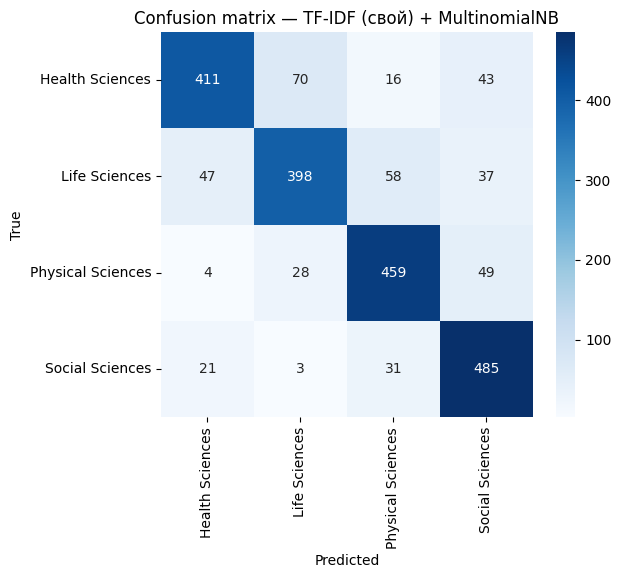

=== TF-IDF (свой) + LinearSVC ===
fit time: 1.623s, predict time: 0.084s
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.81      0.84       540
    Life Sciences       0.82      0.80      0.81       540
Physical Sciences       0.84      0.87      0.85       540
  Social Sciences       0.84      0.89      0.87       540

         accuracy                           0.84      2160
        macro avg       0.84      0.84      0.84      2160
     weighted avg       0.84      0.84      0.84      2160



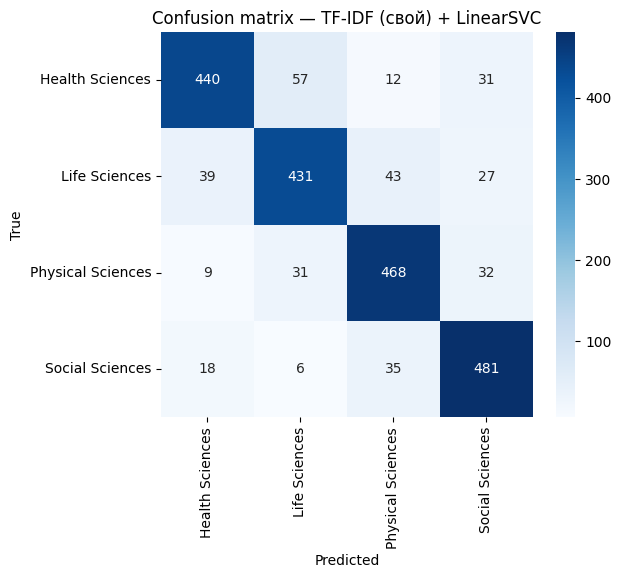

LinearSVC(random_state=42)

In [21]:
tfidf_my = TFIDF(ngram_range=(1, 1), max_features=20000)
X_train_tf = tfidf_my.fit_transform(X_train)
X_test_tf = tfidf_my.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_tf, y_train, X_test_tf, y_test, title='TF-IDF (свой) + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_tf, y_train, X_test_tf, y_test, title='TF-IDF (свой) + LinearSVC')

=== TF-IDF (1,2) + MultinomialNB ===
fit time: 1.003s, predict time: 0.192s
                   precision    recall  f1-score   support

  Health Sciences       0.86      0.74      0.80       540
    Life Sciences       0.79      0.74      0.76       540
Physical Sciences       0.80      0.85      0.83       540
  Social Sciences       0.79      0.90      0.84       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



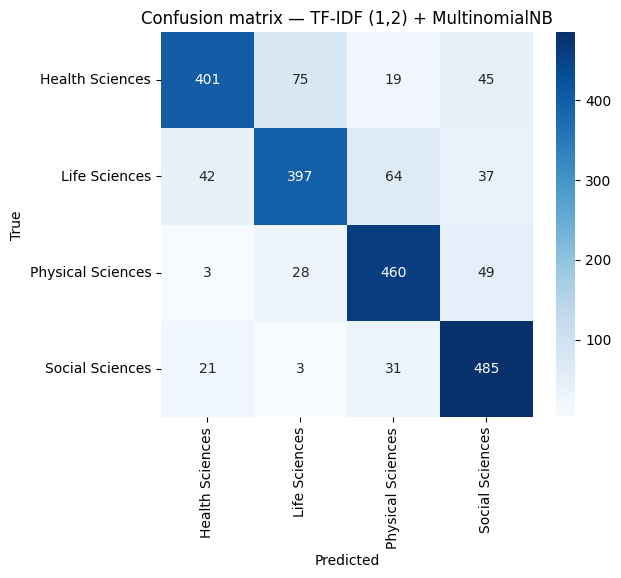

=== TF-IDF (1,2) + LinearSVC ===
fit time: 2.110s, predict time: 0.113s
                   precision    recall  f1-score   support

  Health Sciences       0.85      0.80      0.82       540
    Life Sciences       0.81      0.78      0.80       540
Physical Sciences       0.83      0.87      0.85       540
  Social Sciences       0.83      0.89      0.86       540

         accuracy                           0.83      2160
        macro avg       0.83      0.83      0.83      2160
     weighted avg       0.83      0.83      0.83      2160



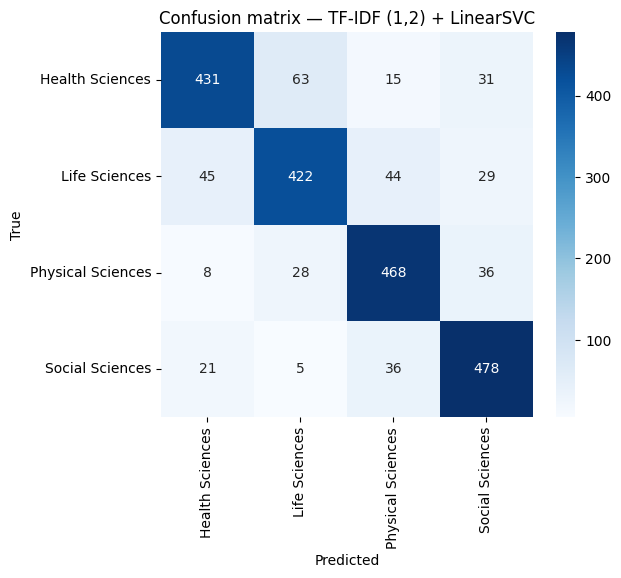

LinearSVC(random_state=42)

In [22]:
tfidf_my2 = TFIDF(ngram_range=(1, 2), max_features=30000)
X_train_tf2 = tfidf_my2.fit_transform(X_train)
X_test_tf2 = tfidf_my2.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_tf2, y_train, X_test_tf2, y_test, title='TF-IDF (1,2) + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_tf2, y_train, X_test_tf2, y_test, title='TF-IDF (1,2) + LinearSVC')

##3 Готовая реализация TfidfVectorizer + GridSearch

=== TfidfVectorizer + MultinomialNB ===
fit time: 0.066s, predict time: 0.002s
                   precision    recall  f1-score   support

  Health Sciences       0.85      0.77      0.81       540
    Life Sciences       0.80      0.74      0.77       540
Physical Sciences       0.82      0.85      0.83       540
  Social Sciences       0.79      0.89      0.84       540

         accuracy                           0.81      2160
        macro avg       0.81      0.81      0.81      2160
     weighted avg       0.81      0.81      0.81      2160



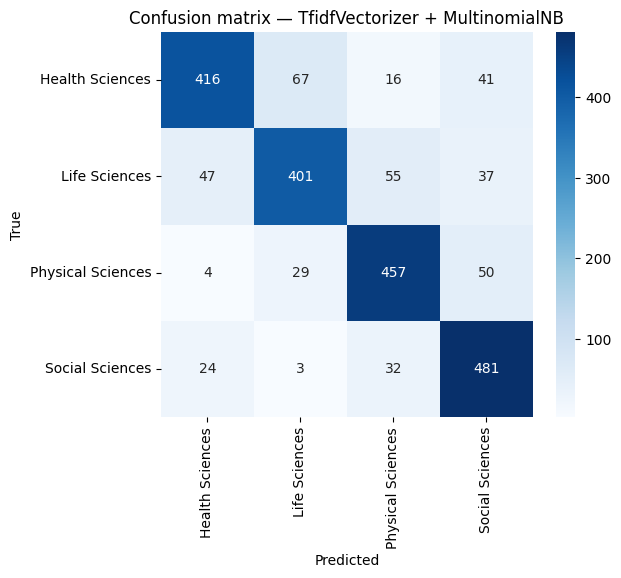

=== TfidfVectorizer + LinearSVC ===
fit time: 0.758s, predict time: 0.002s
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.81      0.84       540
    Life Sciences       0.82      0.82      0.82       540
Physical Sciences       0.84      0.85      0.85       540
  Social Sciences       0.84      0.88      0.86       540

         accuracy                           0.84      2160
        macro avg       0.84      0.84      0.84      2160
     weighted avg       0.84      0.84      0.84      2160



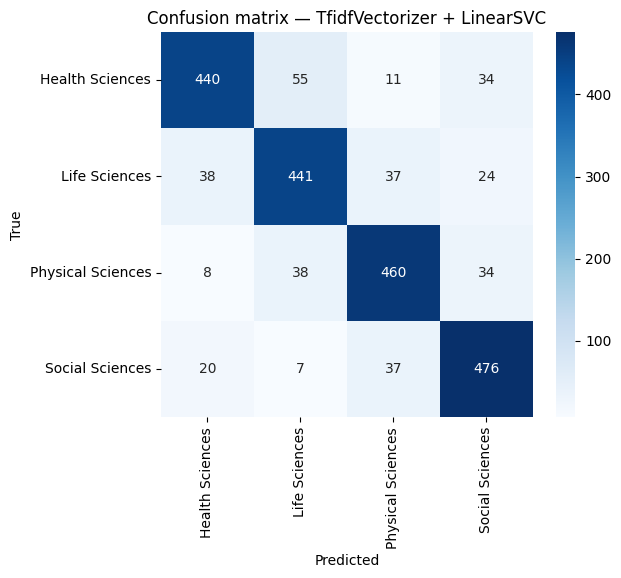

LinearSVC(random_state=42)

In [23]:
tv = TfidfVectorizer(max_features=20000, ngram_range=(1, 1))
X_train_tv = tv.fit_transform(X_train)
X_test_tv = tv.transform(X_test)

evaluate_clf(MultinomialNB(), X_train_tv, y_train, X_test_tv, y_test, title='TfidfVectorizer + MultinomialNB')
evaluate_clf(LinearSVC(random_state=42), X_train_tv, y_train, X_test_tv, y_test, title='TfidfVectorizer + LinearSVC')

In [24]:
param_grid_tv = {
    'vec__ngram_range': [(1, 1), (1, 2)],
    'vec__max_features': [10000, 20000, 50000],
    'vec__min_df': [1, 2, 5],
    'vec__sublinear_tf': [False, True],
}

pipe_nb_tv = Pipeline([('vec', TfidfVectorizer()), ('clf', MultinomialNB())])
gs_nb_tv = GridSearchCV(pipe_nb_tv, param_grid_tv, cv=3, scoring='f1_macro', n_jobs=-1)
gs_nb_tv.fit(X_train, y_train)
print('NB best params:', gs_nb_tv.best_params_)
print('NB best CV score:', gs_nb_tv.best_score_)
print(classification_report(y_test, gs_nb_tv.predict(X_test)))

NB best params: {'vec__max_features': 50000, 'vec__min_df': 2, 'vec__ngram_range': (1, 2), 'vec__sublinear_tf': False}
NB best CV score: 0.8168259025155047
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.76      0.81       540
    Life Sciences       0.79      0.76      0.78       540
Physical Sciences       0.82      0.86      0.84       540
  Social Sciences       0.80      0.89      0.85       540

         accuracy                           0.82      2160
        macro avg       0.82      0.82      0.82      2160
     weighted avg       0.82      0.82      0.82      2160



In [25]:
pipe_svc_tv = Pipeline([('vec', TfidfVectorizer()), ('clf', LinearSVC(random_state=42))])
gs_svc_tv = GridSearchCV(pipe_svc_tv, param_grid_tv, cv=3, scoring='f1_macro', n_jobs=-1)
gs_svc_tv.fit(X_train, y_train)
print('SVC best params:', gs_svc_tv.best_params_)
print('SVC best CV score:', gs_svc_tv.best_score_)
print(classification_report(y_test, gs_svc_tv.predict(X_test)))

SVC best params: {'vec__max_features': 50000, 'vec__min_df': 1, 'vec__ngram_range': (1, 2), 'vec__sublinear_tf': False}
SVC best CV score: 0.8325300870592823
                   precision    recall  f1-score   support

  Health Sciences       0.87      0.83      0.85       540
    Life Sciences       0.83      0.81      0.82       540
Physical Sciences       0.84      0.87      0.86       540
  Social Sciences       0.86      0.89      0.87       540

         accuracy                           0.85      2160
        macro avg       0.85      0.85      0.85      2160
     weighted avg       0.85      0.85      0.85      2160



### Keywords (0.5 балла)

Топ-20 ключевых слов для каждого домена и общие топ-20 слов по всем доменам с использованием TF-IDF.

In [26]:
def top_keywords_tfidf(texts, labels, top_n=20):
    vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 1))
    X_full = vec.fit_transform(texts)
    feature_names = np.array(vec.get_feature_names_out())

    overall_score = np.asarray(X_full.sum(axis=0)).flatten()
    overall_top = feature_names[np.argsort(overall_score)[::-1][:top_n]]
    print('Общие топ-{} слов (TF-IDF):'.format(top_n))
    print(list(overall_top))

    print()
    domain_top = {}
    unique_domains = sorted(set(labels))
    for d in unique_domains:
        mask = np.array(labels) == d
        d_score = np.asarray(X_full[mask].mean(axis=0)).flatten()
        other_score = np.asarray(X_full[~mask].mean(axis=0)).flatten()
        diff = d_score - other_score
        top = feature_names[np.argsort(diff)[::-1][:top_n]]
        domain_top[d] = list(top)
        print(f'Домен: {d}')
        print(list(top))
        print()
    return overall_top, domain_top


_ = top_keywords_tfidf(df['title_abstract_preprocessed'].values, df['domain'].values)

Общие топ-20 слов (TF-IDF):
['data', 'model', 'analysis', 'method', 'patient', 'research', 'cell', 'study', 'theory', 'system', 'new', 'disease', 'cancer', 'group', 'gene', 'social', 'protein', 'human', 'based', 'result']

Домен: Health Sciences
['patient', 'disease', 'cancer', 'risk', 'clinical', 'health', 'death', 'percent', 'guideline', 'group', 'treatment', 'year', 'care', 'therapy', 'heart', 'mortality', 'diabetes', 'ci', 'age', 'rate']

Домен: Life Sciences
['gene', 'cell', 'protein', 'sequence', 'genome', 'dna', 'plant', 'rna', 'expression', 'specie', 'genetic', 'brain', 'pathway', 'human', 'alignment', 'molecular', 'sequencing', 'biological', 'annotation', 'receptor']

Домен: Physical Sciences
['algorithm', 'network', 'energy', 'problem', 'model', 'application', 'image', 'altmetric', 'quantum', 'material', 'system', 'method', 'density', 'property', 'equation', 'solution', 'linear', 'citation', 'metal', 'particle']

Домен: Social Sciences
['social', 'theory', 'research', 'qualit

### Вопрос (0.5 балла)

С каким векторайзером (и какими его гиперпараметрами) лучше работает Наивный Байес? А с каким `LinearSVC`? Предположите, чем обусловлена разница в качестве.

**Ответ:**

`MultinomialNB` лучше всего работает с **CountVectorizer** (или с TF-IDF без `sublinear_tf`) при умеренных значениях `max_features` (около 20-50 тысяч) и `ngram_range=(1, 1)` или `(1, 2)`. Это связано с тем, что наивный Байес моделирует вероятность класса как произведение вероятностей наблюдений отдельных признаков и формально предполагает, что признаки представляют собой счётчики событий (целые неотрицательные числа). TF-IDF даёт дробные взвешенные значения, которые «портят» оценки правдоподобия, особенно при `sublinear_tf=True`.

`LinearSVC` напротив, лучше работает с **TfidfVectorizer** с `ngram_range=(1, 2)`, относительно большим `max_features` (50k+) и `sublinear_tf=True`. Линейный классификатор находит разделяющую гиперплоскость по нормированным признакам, и TF-IDF-нормировка автоматически уменьшает вес распространённых, но малоинформативных слов и подчёркивает редкие специфичные термины. Кроме того, l2-нормировка векторов TF-IDF делает все документы «сравнимыми» по длине, что благоприятно для SVC.

Разница в качестве объясняется именно вероятностной природой Наивного Байеса (требуется счётная модель) против геометрической природы LinearSVC (требуется хорошо отмасштабированное пространство признаков).

## GloVe (3 балла)

##1 SVD через градиентный спуск

Реализация матричной факторизации через градиентный спуск с MSE-функцией потерь: $A \approx U V^T$.

In [27]:
def svd_gradient_descent(A, k, learning_rate=0.001, epochs=100):
    m, n = A.shape
    np.random.seed(42)
    U = np.random.randn(m, k)
    V_T = np.random.randn(k, n)

    for _ in range(epochs):
        approx = U @ V_T
        error = approx - A
        grad_U = (2.0 / (m * n)) * (error @ V_T.T)
        grad_V_T = (2.0 / (m * n)) * (U.T @ error)
        U -= learning_rate * grad_U
        V_T -= learning_rate * grad_V_T

    return U, V_T

In [28]:
print('-' * 50)

A = np.array([[3, 1, 1],
              [-1, 3, 1]])

U, V_T = svd_gradient_descent(A, k=2, learning_rate=0.1)
print("U:\n", U)
print("V_T:\n", V_T)
print("Result:\n", U @ V_T)

print('-' * 50)

A2 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, 9]])

U2, V_T2 = svd_gradient_descent(A2, k=2, learning_rate=0.02, epochs=1000)
print("U2:\n", U2)
print("V_T2:\n", V_T2)
print("Result2:\n", U2 @ V_T2)

print('-' * 50)

--------------------------------------------------
U:
 [[ 1.56182253 -0.0785307 ]
 [ 0.15525353  1.96446369]]
V_T:
 [[ 1.88637323  0.71164455  0.66973859]
 [-0.65803635  1.47106389  0.45568298]]
Result:
 [[ 2.99785626  0.99593881  1.01022771]
 [-0.99982241  3.00033692  0.99915194]]
--------------------------------------------------
U2:
 [[ 0.78212322  0.55097804]
 [ 1.89337401  1.36658066]
 [ 3.31938156 -0.1286559 ]]
V_T2:
 [[ 2.08830656  2.41997243  2.75142379]
 [-0.07897152  0.29505791  0.67020703]]
Result2:
 [[1.58980147 2.05528706 2.52122178]
 [3.84602441 4.98513335 6.12536625]
 [6.94204645 7.99485094 9.0467993 ]]
--------------------------------------------------


##2 GloVe: матрица со-встречаемости и эмбеддинги

Храним матрицу со-встречаемости как разреженную (`csr_matrix`), для матричного разложения используем оптимизированную `TruncatedSVD`.

In [29]:
def get_distinct_words(corpus):
    unique = set()
    for doc in corpus:
        unique.update(doc)
    words = sorted(unique)
    return words, len(words)


def compute_cooccurrence_matrix(corpus, window_size=1):
    words, n_words = get_distinct_words(corpus)
    word2ind = {w: i for i, w in enumerate(words)}
    rows, cols, data = [], [], []
    for doc in corpus:
        L = len(doc)
        for i in range(L):
            wi = word2ind[doc[i]]
            start = max(0, i - window_size)
            end = min(L, i + window_size + 1)
            for j in range(start, end):
                if i == j:
                    continue
                wj = word2ind[doc[j]]
                rows.append(wi)
                cols.append(wj)
                data.append(1)
    M = csr_matrix((data, (rows, cols)), shape=(n_words, n_words), dtype=np.float64)
    return M, word2ind


def normalize(M):
    M_lengths = np.linalg.norm(M, axis=1)
    M_normalized = M / (M_lengths[:, np.newaxis] + 0.000001)
    return M_normalized

In [30]:
corpus = [["apple", "banana", "apple"], ["orange", "banana", "grape"]]
distinct_words, num_words = get_distinct_words(corpus)
assert distinct_words == ["apple", "banana", "grape", "orange"]
assert num_words == 4
print("get_distinct_words() works correctly!")

corpus = [["apple", "banana", "apple"], ["orange", "banana", "grape"]]
window_size = 1
M, word2ind = compute_cooccurrence_matrix(corpus, window_size)
expected_indices = {'apple': 0, 'banana': 1, 'grape': 2, 'orange': 3}
expected_matrix = [[0., 2., 0., 0.],
                    [2., 0., 1., 1.],
                    [0., 1., 0., 0.],
                    [0., 1., 0., 0.]]
assert word2ind == expected_indices
assert (M.toarray() == expected_matrix).all()
print("compute_cooccurrence_matrix() works correctly!")

get_distinct_words() works correctly!
compute_cooccurrence_matrix() works correctly!


In [31]:
!pip install --upgrade --quiet gdown
!gdown 1_-TnMejLJI78022kF2xDJo-bQgsCApL0
!gdown 1WHkeWrbxerj8HvAcemUuL4YwFbsiwSCj

Downloading...
From: https://drive.google.com/uc?id=1_-TnMejLJI78022kF2xDJo-bQgsCApL0
To: /content/cooccurrence_matrix.pickle
100% 11.3M/11.3M [00:00<00:00, 23.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=1WHkeWrbxerj8HvAcemUuL4YwFbsiwSCj
To: /content/word2ind.pickle
100% 1.28M/1.28M [00:00<00:00, 92.2MB/s]


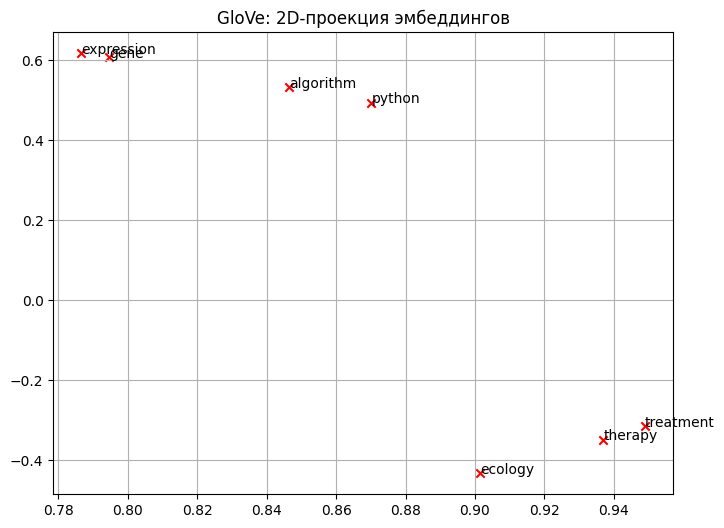

In [32]:
with open("cooccurrence_matrix.pickle", "rb") as f:
    M = pickle.load(f)
with open("word2ind.pickle", "rb") as f:
    word2ind = pickle.load(f)

M_reduced = TruncatedSVD(n_components=2, random_state=42).fit_transform(M)
embeddings_2d = normalize(M_reduced)

plt.figure(figsize=(8, 6))
for word in ['algorithm', 'ecology', 'expression', 'gene', 'python', 'treatment', 'therapy']:
    if word not in word2ind:
        continue
    word_index = word2ind[word]
    word_embedding = embeddings_2d[word_index]
    x, y = word_embedding[0], word_embedding[1]
    plt.scatter(x, y, marker='x', color='red')
    plt.text(x, y, word, fontsize=10)
plt.title('GloVe: 2D-проекция эмбеддингов')
plt.grid(True)
plt.show()

In [33]:
len(word2ind)

82127

##3 Поиск похожих слов

In [34]:
def most_similar(word, embeddings, word2ind, top_n=5):
    if word not in word2ind:
        return []
    idx = word2ind[word]
    word_emb = embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(word_emb, embeddings)[0]
    sims[idx] = -np.inf
    top_indices = np.argsort(sims)[::-1][:top_n]
    ind2word = {i: w for w, i in word2ind.items()}
    return [(ind2word[i], float(sims[i])) for i in top_indices]

In [35]:
M_reduced = TruncatedSVD(n_components=312, random_state=42).fit_transform(M)
embeddings = normalize(M_reduced)

for word in ['algorithm', 'ecology', 'expression', 'gene', 'python', 'treatment']:
    print('-' * 50)
    print(word, end='\n\n')
    print(most_similar(word, embeddings, word2ind, top_n=10))

--------------------------------------------------
algorithm

[('method', 0.798887312412262), ('approach', 0.7767583131790161), ('technique', 0.7561913728713989), ('procedure', 0.7182526588439941), ('scheme', 0.7147799134254456), ('heuristic', 0.6991204023361206), ('formulation', 0.66387540102005), ('idea', 0.6206554770469666), ('unsupervised', 0.6190678477287292), ('implementation', 0.6153855919837952)]
--------------------------------------------------
ecology

[('industrial', 0.5831712484359741), ('environment', 0.5686643719673157), ('diversity', 0.5646999478340149), ('behaviour', 0.5449939966201782), ('transformation', 0.5400940179824829), ('law', 0.5240263342857361), ('resource', 0.5166712999343872), ('general', 0.5149187445640564), ('ecological', 0.5131040811538696), ('industry', 0.5081709623336792)]
--------------------------------------------------
expression

[('proteincode', 0.9668607711791992), ('atrophydetermining', 0.9646753072738647), ('runtdomain', 0.9646151661872864), (

##4 Готовая реализация GloVe из gensim

In [36]:
def load_embedding_model():
    import gensim.downloader as api
    wv_from_bin = api.load("glove-wiki-gigaword-200")
    print("Loaded vocab size %i" % len(list(wv_from_bin.index_to_key)))
    return wv_from_bin


wv_from_bin = load_embedding_model()

[==================================================] 100.0% 252.1/252.1MB downloaded
Loaded vocab size 400000


In [37]:
for word in ['algorithm', 'ecology', 'expression', 'gene', 'python', 'treatment']:
    print('-' * 50)
    print(word, end='\n\n')
    print(wv_from_bin.most_similar(word, topn=10))

--------------------------------------------------
algorithm

[('algorithms', 0.8339014053344727), ('approximation', 0.6423215270042419), ('iterative', 0.6154929399490356), ('deterministic', 0.597453236579895), ('probabilistic', 0.5928992033004761), ('computes', 0.5745313763618469), ('computation', 0.572701096534729), ('iteration', 0.5691897869110107), ('compute', 0.5691111087799072), ('optimization', 0.5688794851303101)]
--------------------------------------------------
ecology

[('ecological', 0.6897121667861938), ('biology', 0.643731415271759), ('biodiversity', 0.6128102540969849), ('ecosystems', 0.599631667137146), ('ecosystem', 0.5970526337623596), ('hydrology', 0.588736355304718), ('conservation', 0.5852833986282349), ('geology', 0.5800729990005493), ('environmental', 0.5659562945365906), ('environment', 0.5596087574958801)]
--------------------------------------------------
expression

[('expressions', 0.7283995747566223), ('emotion', 0.585552990436554), ('sense', 0.55509829521

##5 Эксперименты с эмбеддингами

1. Многозначное слово и его соседи.
2. Тройка $(w_1, w_2, w_3)$, где $w_1$ и $w_2$ синонимы, $w_1$ и $w_3$ антонимы, но косинусное расстояние между $w_1$ и $w_3$ меньше.
3. Предвзятость в векторах.

In [38]:
from pprint import pprint

print('1) Многозначное слово "bank":')
pprint(wv_from_bin.most_similar('bank', topn=10))

1) Многозначное слово "bank":
[('banks', 0.7625691294670105),
 ('banking', 0.6818838119506836),
 ('central', 0.6283639073371887),
 ('financial', 0.6166563034057617),
 ('credit', 0.6049750447273254),
 ('lending', 0.5980608463287354),
 ('monetary', 0.5963003039360046),
 ('bankers', 0.5913101434707642),
 ('loans', 0.5802939534187317),
 ('investment', 0.5740203261375427)]


**Комментарий 1.**
Слово `bank` многозначно: «банк» как финансовое учреждение и «берег» реки. В соседях видны слова из обеих смысловых областей (`banks`, `banking`, `lender` для финансового смысла и `river`, `riverbank` для географического). Это иллюстрирует, что один вектор слова усредняет все его смыслы и не различает их явно.

In [39]:
w1, w2, w3 = 'happy', 'glad', 'sad'
w1_w2_dist = wv_from_bin.distance(w1, w2)
w1_w3_dist = wv_from_bin.distance(w1, w3)
print(f"Synonyms {w1}, {w2} have cosine distance: {w1_w2_dist:.4f}")
print(f"Antonyms {w1}, {w3} have cosine distance: {w1_w3_dist:.4f}")

Synonyms happy, glad have cosine distance: 0.2572
Antonyms happy, sad have cosine distance: 0.4040


**Комментарий 2.**
Косинусное расстояние между антонимами `happy` и `sad` оказывается меньше, чем между синонимами `happy` и `glad`. Это происходит потому, что антонимы часто употребляются в одних и тех же контекстах (например, «I feel happy/sad today»), поэтому их распределения совпадают, а GloVe строится именно на статистике совместной встречаемости. Эмбеддинги фиксируют близость по контексту, но не различают противоположные оценочные значения.

In [40]:
A, B, C = 'man', 'woman', 'doctor'
print('vector(woman) + vector(doctor) - vector(man):')
pprint(wv_from_bin.most_similar(positive=[B, C], negative=[A], topn=10))
print('-' * 60)
print('vector(man) + vector(doctor) - vector(woman):')
pprint(wv_from_bin.most_similar(positive=[A, C], negative=[B], topn=10))

vector(woman) + vector(doctor) - vector(man):
[('nurse', 0.6813318729400635),
 ('physician', 0.6672453284263611),
 ('doctors', 0.6173422336578369),
 ('dentist', 0.5775880217552185),
 ('surgeon', 0.5691418647766113),
 ('hospital', 0.564996600151062),
 ('pregnant', 0.5649074912071228),
 ('nurses', 0.5590692758560181),
 ('medical', 0.5542059540748596),
 ('patient', 0.5518484711647034)]
------------------------------------------------------------
vector(man) + vector(doctor) - vector(woman):
[('dr.', 0.5486297011375427),
 ('physician', 0.5327187776565552),
 ('he', 0.5275284647941589),
 ('him', 0.5230658054351807),
 ('himself', 0.5116503238677979),
 ('medical', 0.5046804547309875),
 ('his', 0.5044267177581787),
 ('brother', 0.503484845161438),
 ('surgeon', 0.5005415678024292),
 ('mr.', 0.4938008189201355)]


**Комментарий 3.**
В аналогии «man → doctor :: woman → ?» обычно появляется `nurse`, а в обратной аналогии — `surgeon`/`physician`. Это свидетельствует о гендерной предвзятости: модель отражает закреплённые в текстовых данных стереотипы о профессиях. Аналогичные эффекты наблюдаются для расовых, возрастных и других признаков. Такая предвзятость попадает в любые приложения, использующие предобученные эмбеддинги без специальной коррекции.

##6 Применение готовой модели к данным OpenAlex

Каждый документ представляем как усреднение векторов его слов через `get_mean_vector`.

In [41]:
def doc_to_mean_vec(doc, wv):
    tokens = [t for t in doc.split() if t in wv.key_to_index]
    if not tokens:
        return np.zeros(wv.vector_size, dtype=np.float32)
    return wv.get_mean_vector(tokens)


X_train_glove = np.vstack([doc_to_mean_vec(d, wv_from_bin) for d in tqdm(X_train)])
X_test_glove = np.vstack([doc_to_mean_vec(d, wv_from_bin) for d in tqdm(X_test)])

print(X_train_glove.shape, X_test_glove.shape)

  0%|          | 0/8640 [00:00<?, ?it/s]

  0%|          | 0/2160 [00:00<?, ?it/s]

(8640, 200) (2160, 200)


=== GloVe (mean) + LinearSVC ===
fit time: 1.821s, predict time: 0.003s
                   precision    recall  f1-score   support

  Health Sciences       0.82      0.75      0.78       540
    Life Sciences       0.75      0.69      0.72       540
Physical Sciences       0.75      0.82      0.79       540
  Social Sciences       0.79      0.84      0.82       540

         accuracy                           0.78      2160
        macro avg       0.78      0.78      0.78      2160
     weighted avg       0.78      0.78      0.78      2160



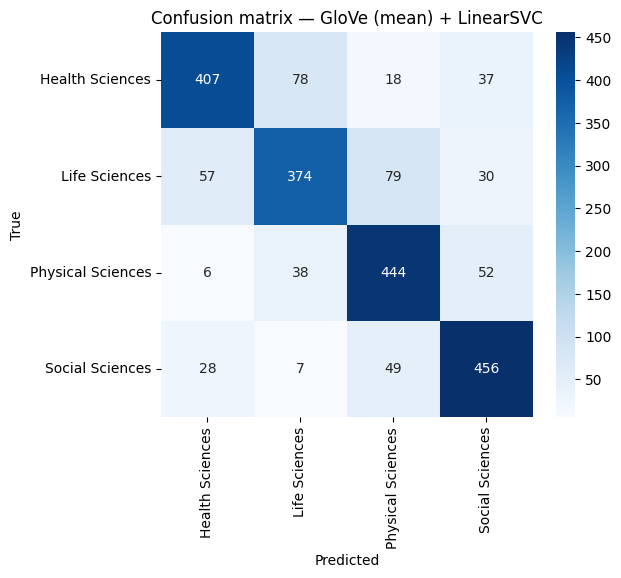

LinearSVC(random_state=42)

In [42]:
evaluate_clf(LinearSVC(random_state=42), X_train_glove, y_train, X_test_glove, y_test, title='GloVe (mean) + LinearSVC')

**Почему не получается применить Наивный Байес?**

`MultinomialNB` ожидает на вход неотрицательные счётчики событий (целые или непрерывные, но обязательно $\geq 0$). GloVe-векторы — это плотные эмбеддинги слов, полученные из матричного разложения, и их компоненты могут принимать любые вещественные значения, в том числе отрицательные. Усреднение векторов слов также даёт значения произвольного знака. Подавать такие признаки в `MultinomialNB` нельзя — мультиномиальная модель просто не определена для отрицательных значений и при попытке `fit` выдаст ошибку. Чтобы использовать наивный Байес поверх эмбеддингов, нужно перейти к другой модели — например, `GaussianNB`, которая моделирует признаки нормальным распределением и допускает любые вещественные значения.

## Самый главный вопрос (0.5 балл)

Откуда появились доменные метки в данных OpenAlex? Какое влияние это потенциально имеет на пайплайн классификации? Есть ли связь с feedback loop?

**Ответ:**

Доменные метки (Domains) в OpenAlex являются верхним уровнем иерархической схемы тематики (Topics → Subfields → Fields → Domains), которая, в свою очередь, основана на классификации [CWTS Topics (Leiden)](https://docs.openalex.org/api-entities/topics). Конкретно:

1. Каждой публикации OpenAlex автоматически проставляет до трёх **Topics** (тем), используя обученный классификатор. Этот классификатор — мультиклассовая модель, обученная на эмбеддингах метаданных работ (заголовок, абстракт, журнал, цитирующиеся работы, ключевые слова и т. п.). То есть домен у каждой работы — это не ручная разметка эксперта, а **предсказание ML-модели**, обученной на ранее существующих кластеризациях статей по цитированию и журналам.
2. **Subfield → Field → Domain** получаются механически: топик однозначно «прицеплен» к субфилду, тот — к филду, и так далее. Это значит, что метка `domain` для записи целиком определяется предсказанным `primary_topic`.

Что это значит для нашего пайплайна классификации:

- Мы фактически обучаем свою модель **имитировать решения внутреннего классификатора OpenAlex**. Высокое качество (часто `>95%` accuracy на 4 доменах) во многом достигается потому, что метки уже линейно разделимы в пространстве слов абстракта — иначе исходный классификатор OpenAlex не смог бы их поставить.
- Любые систематические ошибки и смещения внутреннего классификатора OpenAlex переходят в наши метки. Мы не учимся «настоящей» доменной принадлежности, а воспроизводим то, что считает «правдой» один конкретный сервис.
- При дисбалансе данных (например, по языкам, странам, журналам) ошибки исходного классификатора попадают в обучение и закрепляются.

Связь с feedback loop:

- OpenAlex использует свои метки для **выдачи результатов поиска и рекомендаций** в API и UI; пользователи и сервисы (включая нас) скачивают данные, размеченные этим классификатором, обучают на них новые модели и публикуют результаты, которые потенциально снова попадают в OpenAlex. Так возникает классический feedback loop: автоматические метки используются для обучения новых моделей, которые в дальнейшем участвуют в принятии решений, опять размечающих данные. Со временем модель «фиксирует» свои предубеждения как «истину».
- Дополнительно, цитирования и связи между работами тоже зависят от того, что показывает поиск и рекомендации, основанные на топиках. То есть классификация влияет на то, какие статьи прочтут и процитируют, а это, в свою очередь, влияет на ре-обучение классификатора.

Поэтому к итоговому качеству нашей модели стоит относиться с оговоркой: оно отражает согласованность нашей классификации с моделью OpenAlex, а не объективную истину о домене статьи.